 🧩 GMM - Gaussian Mixture Model - Tips dataset


![iris.png](https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F19517213%2F49afcbc1ea63ba5f522e6aec5a75016f%2F1lodging_housespecialty_finish1.webp?generation=1711445992879706&alt=media)




---

## 🎯 Objectius
- Aquest notebook mostra un exemple d'ús del model GMM i el compara amb K-means per un dataset força utilitzat anomenat (tips/propines)

## 📦 Dataset Tips/Propines
- Utilitzarem el dataset tips:
   - **total_bill**: L’import total del compte, incloent el cost del menjar i les begudes.
   - **tip**: La propina donada pel client.
   - **sex**: El gènere del client (Male/Female)).
   - **smoker**: Indica si el client és fumador o no (ture/false).
   - **day**: El dia de la setmana en què es va produir la transacció (Sun,Mon,Thurm,Fri).
   - **time**: El moment del dia en què es va produir la transacció (Dinner,Lunch).
   - **size**: La mida del grup o nombre de comensals.

## 🟦 1. Import Classes

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

sns.set(style="whitegrid", context="notebook")



## 🟦 1. Load Data

In [34]:
import os
from google.colab import drive

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/M0572-SistemesAprenentatgeAutomatic/03_models_no_supervisats/datasets/')
os.getcwd()

df = pd.read_csv('tip.csv')
#cars = pd.read_csv('data/used_cars_data.csv', index_col=None)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 🟦 2. Visualització

Veiem un histograma de les variables `tip` i `total_bill`. Podem observar en els gràfics que totes dues no segueixen una distribució normal.

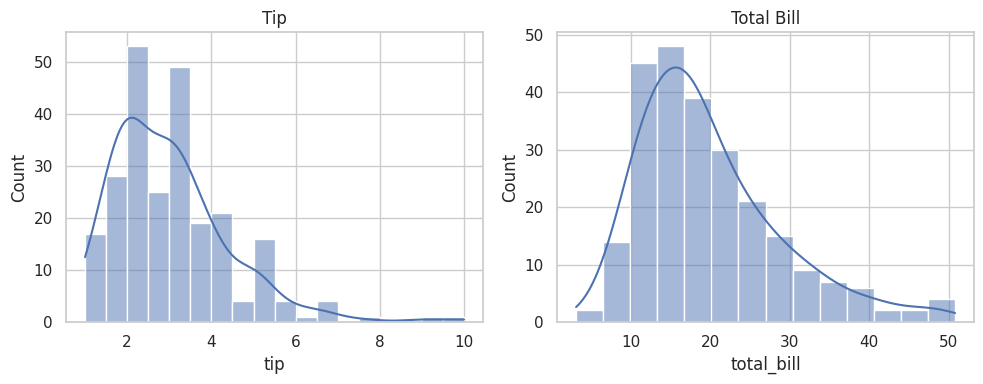

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(data=df, x='tip', kde=True, ax=axes[0])
axes[0].set_title("Tip")


sns.histplot(data=df, x='total_bill', kde=True, ax=axes[1])
axes[1].set_title("Total Bill")

plt.tight_layout()
plt.show()

## 🟦 3. Entrenament

In [36]:
feature_cols = ['total_bill', 'tip']
X = df[feature_cols].copy()

In [37]:
X

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61
...,...,...
239,29.03,5.92
240,27.18,2.00
241,22.67,2.00
242,17.82,1.75


In [38]:
k = 2

kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    algorithm="lloyd",
    random_state=42
)

prediction_kmeans = kmeans.fit_predict(X)

gmm = GaussianMixture(
      n_components=k,
      covariance_type='full'
)
prediction_gmm = gmm.fit_predict(X)

# Afegim els clustes a dins el nostre dataset inicial
df['kmeans_cluster'] = prediction_kmeans
df['gmm_cluster'] = prediction_gmm
df.head()


,total_bill,tip,sex,smoker,day,time,size,kmeans_cluster,gmm_cluster
0,16.99,1.01,Female,No,Sun,Dinner,2,1,1
1,10.34,1.66,Male,No,Sun,Dinner,3,1,0
2,21.01,3.50,Male,No,Sun,Dinner,3,1,0
3,23.68,3.31,Male,No,Sun,Dinner,2,0,0
4,24.59,3.61,Female,No,Sun,Dinner,4,0,0


## 🟦 4. Visualització

Mostrem 2 conjunts scatter plots a on es mostren les classes trobades per K-Means i GMM.

**K-Means** funciona tal com s'esperava, amb divisions de forma circular. Podem veure un clúster amb factures totals fins a aproximadament 23 i propines fins a 5,5. La resta correspon al clúster amb imports totals més elevats.

**GMM** amb el tipus de covariància `full` ens proporciona un clúster  més compacte (blau), amb propines molt proporcionals respecte al compte total, i un clúster (taronja) amb valors més dispersos. Tenen formes diferents.

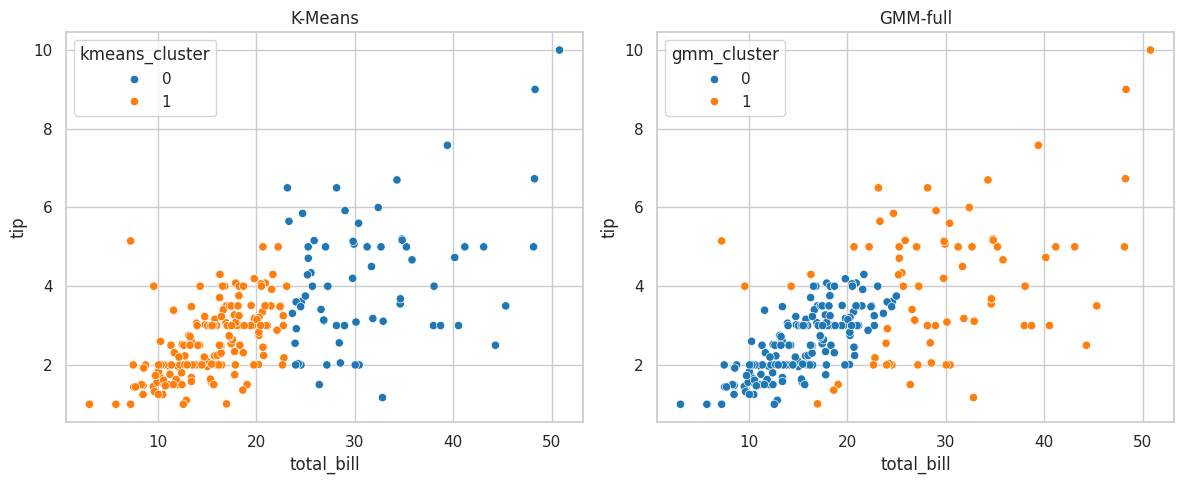

In [39]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(
    data=df, y='tip', x='total_bill',
    hue='kmeans_cluster', palette="tab10", ax=axes[0]);

axes[0].set_title("K-Means")

sns.scatterplot(
    data=df, y='tip', x='total_bill',
    hue="gmm_cluster", palette="tab10", ax=axes[1]
)
axes[1].set_title("GMM-full")

plt.tight_layout()
plt.show()

## 🟦 5. Mirem altres covariàncies

In [40]:
# @title
covariances = ['full','tied','diagonal', 'spherical']
for cov in covariances:
  gmm = GaussianMixture(
        n_components=k,
        covariance_type='tied'
  )
  # el predict() retorna el component més probable (hard label)
  prediction_gmm = gmm.fit_predict(X)
  pred_soft = gmm.predict_proba(X)

  #Reemplaçaem els clusters de GMM
  df[f'gmm_cluster_{cov}'] = prediction_gmm
  df[f'gmm_cluster_{cov}_confidence'] = pred_soft.max(axis=1)

df.head(100)


,total_bill,tip,sex,smoker,day,time,size,kmeans_cluster,gmm_cluster,gmm_cluster_full,gmm_cluster_full_confidence,gmm_cluster_tied,gmm_cluster_tied_confidence,gmm_cluster_diagonal,gmm_cluster_diagonal_confidence,gmm_cluster_spherical,gmm_cluster_spherical_confidence
0,16.99,1.01,Female,No,Sun,Dinner,2,1,1,0,0.989306,0,0.989306,1,0.989306,1,0.989306
1,10.34,1.66,Male,No,Sun,Dinner,3,1,0,0,0.999986,0,0.999986,1,0.999986,1,0.999986
2,21.01,3.50,Male,No,Sun,Dinner,3,1,0,0,0.997955,0,0.997955,1,0.997955,1,0.997955
3,23.68,3.31,Male,No,Sun,Dinner,2,0,0,0,0.975170,0,0.975170,1,0.975170,1,0.975170
4,24.59,3.61,Female,No,Sun,Dinner,4,0,0,0,0.971495,0,0.971495,1,0.971495,1,0.971495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,40.17,4.73,Male,Yes,Fri,Dinner,4,0,1,1,0.998880,1,0.998880,0,0.998880,0,0.998880
96,27.28,4.00,Male,Yes,Fri,Dinner,2,0,1,0,0.894071,0,0.894071,1,0.894071,1,0.894071
97,12.03,1.50,Male,Yes,Fri,Dinner,2,1,0,0,0.999923,0,0.999923,1,0.999923,1,0.999923
98,21.01,3.00,Male,Yes,Fri,Dinner,2,1,0,0,0.994554,0,0.994554,1,0.994554,1,0.994554


In [41]:

print("Means (els 'centres' de cada component):")
display(pd.DataFrame(gmm.means_, columns=feature_cols))

print("Weights (pes de cada component):")
print(gmm.weights_)

print("Covariances (forma/escala):")
print(gmm.covariances_)

Means (els 'centres' de cada component):


,total_bill,tip
0,35.455357,3.967213
1,17.093122,2.831765


Weights (pes de cada component):
[0.14664994 0.85335006]
Covariances (forma/escala):
[[36.73320961  5.68022341]
 [ 5.68022341  1.74526914]]


## 🟦 5. Selecció de K: AIC (*Akaike Information Criterion*) i BIC (*Bayesian Information Criterion*)

AIC/BIC ajuden a triar K equilibrant:

* qualitat d'ajust
* complexitat del model

Regla pràctica: **més baix = millor.**

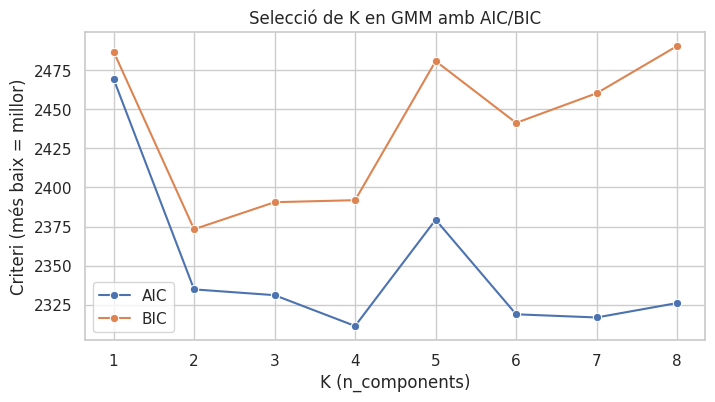

,K,AIC,BIC
0,1,2469.441372,2486.927213
1,2,2334.823495,2373.292346
2,3,2331.125597,2390.577457
3,4,2311.421154,2391.856024
4,5,2379.366576,2480.784454
5,6,2318.892135,2441.293023
6,7,2316.863702,2460.247599
7,8,2326.088264,2490.455170


In [42]:

Ks = range(1, 9)
aics, bics = [], []

for k in Ks:
    m = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    m.fit(X)
    aics.append(m.aic(X))
    bics.append(m.bic(X))

plt.figure(figsize=(8,4))
sns.lineplot(x=list(Ks), y=aics, marker="o", label="AIC")
sns.lineplot(x=list(Ks), y=bics, marker="o", label="BIC")
plt.title("Selecció de K en GMM amb AIC/BIC")
plt.xlabel("K (n_components)")
plt.ylabel("Criteri (més baix = millor)")
plt.legend()
plt.show()

pd.DataFrame({"K": list(Ks), "AIC": aics, "BIC": bics})